# Atelier Seaborn — Analyse exploratoire de capteurs IoT

**Contexte :** Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure. Après avoir utilisé NumPy pour manipuler les données numériques, Pandas pour importer, nettoyer et analyser le dataset et Matplotlib pour réaliser des visualisations, l'étape suivante consiste à se servir de Seaborn pour réaliser une analyse exploratoire plus riche des données. 

## Préparation

### 4) Installer et importer seaborn, matplotlib, pandas, numpy

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

### 5) Importer `mesures_capteurs.csv` dans le dataframe `df`

In [61]:
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


### 6) Vérifier le contenu du dataframe `df`


In [62]:
df.shape


(605, 9)

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [64]:
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


In [65]:
df.isnull().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

---
## Partie 1 – Distribution d'une variable avec `histplot()`

### 1) Afficher la distribution des temperatures

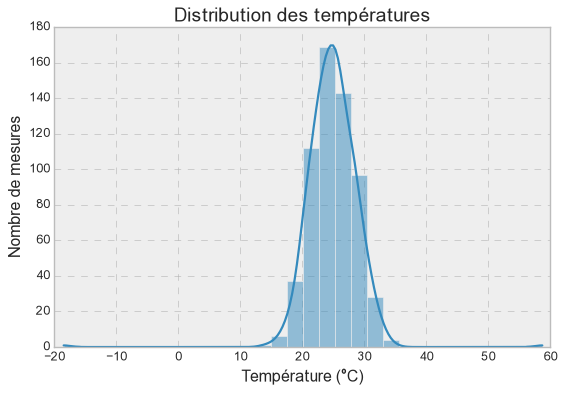

In [66]:
sns.set_theme(style="darkgrid", palette="pastel")
plt.style.use("bmh")
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="temperature", bins=30, kde=True)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")


plt.show()

### 2) Autour de quelle valeur les températures sont concentrées ?

D’après l’histogramme, les températures sont principalement concentrées autour de 25 °C. La majorité des mesures se trouve dans une zone assez proche de cette valeur.

### 3) La distribution semble-t-elle symétrique ?

Oui, la distribution est globalement assez symétrique autour de sa valeur centrale. Elle présente une forme proche d’une courbe en cloche, avec une forte concentration des températures au centre et moins de mesures lorsqu’on s’éloigne de cette zone.

### 4) Existe-t-il des valeurs extrêmes ?

Oui. On remarque quelques valeurs très éloignées de la majorité des observations, notamment aux deux extrémités de l’histogramme. Elles sont très peu nombreuses et peuvent correspondre à des valeurs anormales ou à des erreurs de mesure.

### 5) Modifier le nombre de classes (bins)

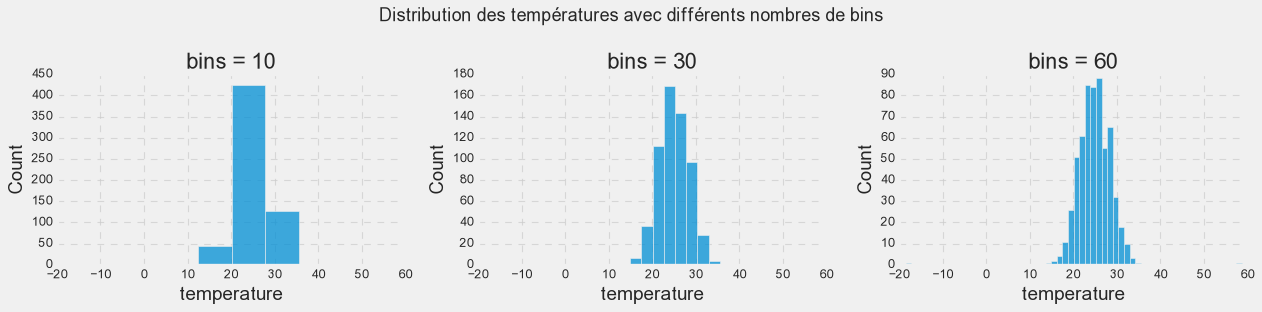

In [78]:
sns.set_theme(style="darkgrid", palette="bright")
plt.style.use("fivethirtyeight")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=df, x="temperature", bins=10, ax=axes[0])
axes[0].set_title("bins = 10")

sns.histplot(data=df, x="temperature", bins=30, ax=axes[1])
axes[1].set_title("bins = 30")

sns.histplot(data=df, x="temperature", bins=60, ax=axes[2])
axes[2].set_title("bins = 60")

plt.suptitle("Distribution des températures avec différents nombres de bins", fontsize=16)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

### 6) Afficher la distribution des températures par bâtiment 

**Observation :** avec peu de classes (`bins=10`), on voit la tendance générale mais on perd du détail. Avec beaucoup de classes (`bins=60`), on voit mieux les valeurs extrêmes isolées, mais le graphique devient plus "bruité". `bins=30` est un bon compromis ici.

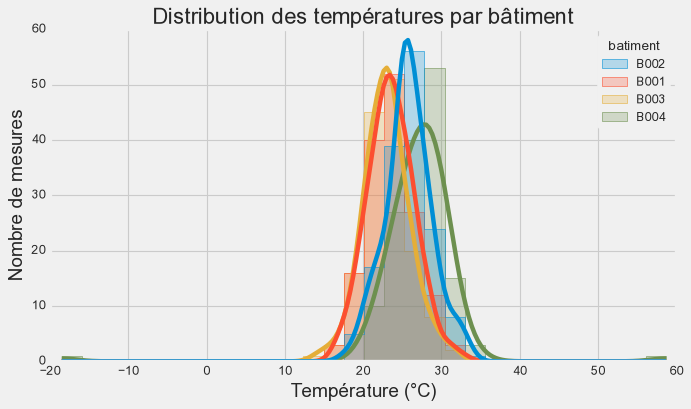

In [79]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="temperature", hue="batiment", bins=30, kde=True, element="step")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.show()

---
## Partie 2 – Distribution d'une variable avec `kdeplot()`

### 1) Afficher la distribution des températures

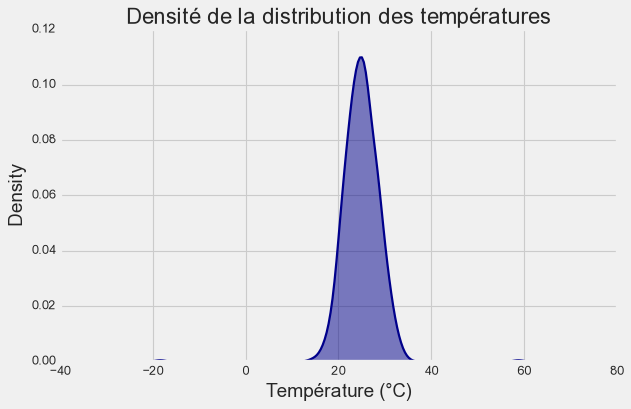

In [82]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="temperature", fill=True,color="darkblue", alpha=0.5, linewidth=2)
plt.title("Densité de la distribution des températures")
plt.xlabel("Température (°C)")
plt.show()

### 2) Afficher la distribution des températures par bâtiment

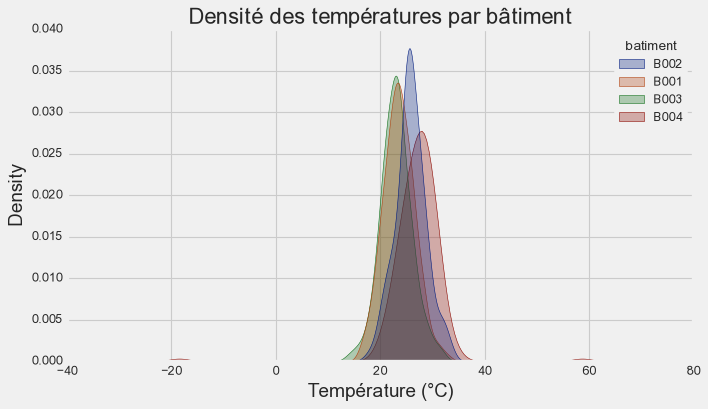

In [98]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="temperature", hue="batiment",palette="dark", fill=True, alpha=0.3)
plt.title("Densité des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.show()